In [6]:
import os, json, glob
import numpy as np
import torch
from safetensors.torch import load_file
from ripser import ripser
import matplotlib.pyplot as plt

def read_manifest(out_dir):
    path = os.path.join(out_dir, "manifest.jsonl")
    steps = []
    metas = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            m = json.loads(line)
            if "step" in m:
                steps.append(int(m["step"]))
                metas.append(m)
    # 去重 + 排序
    uniq = {}
    for s, m in zip(steps, metas):
        uniq[s] = m
    steps = sorted(uniq.keys())
    metas = [uniq[s] for s in steps]
    return steps, metas

def pick_uniform_steps(steps, n=100):
    steps = np.array(sorted(steps))
    if len(steps) <= n:
        return steps.tolist()
    targets = np.linspace(steps[0], steps[-1], n)
    # 对每个 target 选最近的实际 step
    picked = []
    j = 0
    for t in targets:
        idx = int(np.argmin(np.abs(steps - t)))
        picked.append(int(steps[idx]))
    # 去重保持顺序
    out = []
    seen = set()
    for s in picked:
        if s not in seen:
            out.append(s); seen.add(s)
    return out

def load_tok_emb(out_dir, step):
    tag = f"step_{step:07d}"
    w_path = os.path.join(out_dir, "snapshots", f"{tag}.safetensors")
    sd = load_file(w_path)  # cpu tensors (float32)
    # 你的模型里 embedding 参数名一般是 "tok_emb.weight"
    X = sd["tok_emb.weight"].numpy()  # (p, d)
    return X

def preprocess_points(X, mode="center_norm", eps=1e-12):
    # X: (n, d)
    if mode == "raw":
        return X.astype(np.float64)
    elif mode == "center":
        Y = X - X.mean(axis=0, keepdims=True)
        return Y.astype(np.float64)
    elif mode == "center_norm":
        Y = X - X.mean(axis=0, keepdims=True)
        norms = np.linalg.norm(Y, axis=1, keepdims=True)
        Y = Y / (norms + eps)
        return Y.astype(np.float64)
    else:
        raise ValueError(mode)

def choose_thresh_from_dist(X, q=0.95):
    # 基于 pairwise 距离分位数定 thresh
    # n=113 不大，直接算也没问题
    from scipy.spatial.distance import pdist
    d = pdist(X, metric="euclidean")
    return float(np.quantile(d, q))

def h0_death_stats(dgm0):
    # dgm0: (m,2) birth, death
    if dgm0.size == 0:
        return {
            "H0_death_max": 0.0,
            "H0_death_mean": 0.0,
            "H0_death_median": 0.0,
            "H0_death_q90": 0.0,
            "H0_death_count_finite": 0,
        }
    d = dgm0[:, 1]
    finite = np.isfinite(d)
    d = d[finite]  # 去掉 inf
    if d.size == 0:
        return {
            "H0_death_max": 0.0,
            "H0_death_mean": 0.0,
            "H0_death_median": 0.0,
            "H0_death_q90": 0.0,
            "H0_death_count_finite": 0,
        }
    return {
        "H0_death_max": float(np.max(d)),
        "H0_death_mean": float(np.mean(d)),
        "H0_death_median": float(np.median(d)),
        "H0_death_q90": float(np.quantile(d, 0.90)),
        "H0_death_count_finite": int(d.size),
    }


def diag_summaries(dgm, k=1, tau=None):
    # dgm: (m,2) birth, death
    if dgm.size == 0:
        return {
            f"H{k}_count": 0,
            f"H{k}_max_pers": 0.0,
            f"H{k}_total_pers_1": 0.0,
            f"H{k}_total_pers_2": 0.0,
            f"H{k}_entropy": 0.0,
            f"H{k}_count_gt_tau": 0 if tau is not None else None,
        }
    b = dgm[:,0]
    d = dgm[:,1]
    # ripser 对“无穷大 death”会用 inf；H0 会有一个 inf
    finite = np.isfinite(d)
    b = b[finite]; d = d[finite]
    if b.size == 0:
        return {
            f"H{k}_count": 0,
            f"H{k}_max_pers": 0.0,
            f"H{k}_total_pers_1": 0.0,
            f"H{k}_total_pers_2": 0.0,
            f"H{k}_entropy": 0.0,
            f"H{k}_count_gt_tau": 0 if tau is not None else None,
        }
    l = d - b
    max_p = float(np.max(l)) if l.size else 0.0
    tp1 = float(np.sum(l))
    tp2 = float(np.sum(l**2))
    # entropy
    s = np.sum(l)
    if s <= 0:
        ent = 0.0
    else:
        p = l / s
        ent = float(-np.sum(p * np.log(p + 1e-12)))
    cnt_tau = None
    if tau is not None:
        cnt_tau = int(np.sum(l > tau))
    return {
        f"H{k}_count": int(l.size),
        f"H{k}_max_pers": max_p,
        f"H{k}_total_pers_1": tp1,
        f"H{k}_total_pers_2": tp2,
        f"H{k}_entropy": ent,
        f"H{k}_count_gt_tau": cnt_tau,
    }

def betti_curve(dgm, eps_grid):
    # beta(eps)=#{(b,d): b<=eps<d}
    if dgm.size == 0:
        return np.zeros_like(eps_grid, dtype=np.int32)
    b = dgm[:,0]
    d = dgm[:,1]
    finite = np.isfinite(d)
    b = b[finite]; d = d[finite]
    if b.size == 0:
        return np.zeros_like(eps_grid, dtype=np.int32)
    # 向量化计算
    # beta_j(eps) = (b_j <= eps) & (eps < d_j)
    E = eps_grid[None, :]
    B = b[:, None]
    D = d[:, None]
    alive = (B <= E) & (E < D)
    return alive.sum(axis=0).astype(np.int32)

def run_tda_over_time(out_dir, n_slices=100, pre_mode="center_norm", dist_q=0.95, maxdim=1):
    steps, metas = read_manifest(out_dir)
    pick = pick_uniform_steps(steps, n=n_slices)

    # 先用所有切片的 H1 persistence 分布确定一个全局 tau（可选）
    all_h1_pers = []
    tmp_cache = {}
    for s in pick:
        X = preprocess_points(load_tok_emb(out_dir, s), mode=pre_mode)
        thresh = choose_thresh_from_dist(X, q=dist_q)
        res = ripser(X, maxdim=maxdim, thresh=thresh)
        dgm1 = res["dgms"][1] if len(res["dgms"]) > 1 else np.zeros((0,2))
        if dgm1.size:
            finite = np.isfinite(dgm1[:,1])
            l = (dgm1[finite,1] - dgm1[finite,0])
            all_h1_pers.extend(l.tolist())
        tmp_cache[s] = (X, thresh, res)

    tau = None
    if len(all_h1_pers) > 0:
        tau = float(np.quantile(np.array(all_h1_pers), 0.90))  # 你也可以改成 0.95
    print("Global H1 tau =", tau)

    records = []
    # 为 betti curve 固定 eps 网格：用所有切片 thresh 的中位数做上限
    thresh_med = float(np.median([tmp_cache[s][1] for s in pick]))
    eps_grid = np.linspace(0.0, thresh_med, 128)

    for s in pick:
        X, thresh, res = tmp_cache[s]
        dgms = res["dgms"]
        dgm0 = dgms[0]
        dgm1 = dgms[1] if len(dgms) > 1 else np.zeros((0,2))

        rec = {"step": int(s), "thresh": float(thresh), "pre_mode": pre_mode}
        rec.update(diag_summaries(dgm0, k=0, tau=None))
        rec.update(diag_summaries(dgm1, k=1, tau=tau))
        rec.update(h0_death_stats(dgm0))


        b0 = betti_curve(dgm0, eps_grid)
        b1 = betti_curve(dgm1, eps_grid)
        rec["betti0_auc"] = float(np.trapz(b0, eps_grid))
        rec["betti1_auc"] = float(np.trapz(b1, eps_grid))
        rec["betti1_peak"] = int(np.max(b1)) if b1.size else 0
        rec["betti1_peak_eps"] = float(eps_grid[int(np.argmax(b1))]) if b1.size else 0.0

        records.append(rec)

    # save json
    out_json = os.path.join(out_dir, f"tda_tok_emb_{pre_mode}.jsonl")
    with open(out_json, "w", encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(r) + "\n")
    print("Saved:", out_json)

    # plot a few key curves
    steps_arr = np.array([r["step"] for r in records])
    h1_max = np.array([r["H1_max_pers"] for r in records])
    h1_tp1 = np.array([r["H1_total_pers_1"] for r in records])
    h1_ent = np.array([r["H1_entropy"] for r in records])
    b1_auc = np.array([r["betti1_auc"] for r in records])

    def simple_plot(y, name):
        plt.figure()
        plt.plot(steps_arr, y)
        plt.xlabel("step"); plt.ylabel(name); plt.grid(True)
        plt.title(f"{name} over time ({pre_mode})")
        p = os.path.join(out_dir, f"{name}_{pre_mode}.png")
        plt.savefig(p, dpi=200)
        print("Saved:", p)

    simple_plot(h1_max, "H1_max_persistence")
    simple_plot(h1_tp1, "H1_total_persistence_L1")
    simple_plot(h1_ent, "H1_entropy")
    simple_plot(b1_auc, "Betti1_AUC")

    h0_max = np.array([r["H0_death_max"] for r in records])
    h0_med = np.array([r["H0_death_median"] for r in records])
    h0_q90 = np.array([r["H0_death_q90"] for r in records])
    b0_auc = np.array([r["betti0_auc"] for r in records])

    simple_plot(h0_max, "H0_death_max")
    simple_plot(h0_med, "H0_death_median")
    simple_plot(h0_q90, "H0_death_q90")
    simple_plot(b0_auc, "Betti0_AUC")


    return records

# 用法示例：
# records = run_tda_over_time("./runs/modadd_1", n_slices=100, pre_mode="center_norm", dist_q=0.95, maxdim=1)


c:\Users\tangy\.conda\envs\env_01\lib\site-packages\ripser\ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\tangy\.conda\envs\env_01\lib\site-packages\ripser\ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\tangy\.conda\envs\env_01\lib\site-packages\ripser\ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\tangy\.conda\envs\env_01\lib\site-packages\ripser\ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\tangy\.conda\envs\env_01\lib\site-packages\ripser\ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\tangy\.conda\envs\env_01\lib\site-packages\ripser\ripser.py:257: UserWarning: The inpu

Global H1 tau = 0.09332139492034912
Saved: ./runs/modadd_grokking_03\tda_tok_emb_center_norm.jsonl
Saved: ./runs/modadd_grokking_03\H1_max_persistence_center_norm.png
Saved: ./runs/modadd_grokking_03\H1_total_persistence_L1_center_norm.png
Saved: ./runs/modadd_grokking_03\H1_entropy_center_norm.png
Saved: ./runs/modadd_grokking_03\Betti1_AUC_center_norm.png
Saved: ./runs/modadd_grokking_03\H0_death_max_center_norm.png
Saved: ./runs/modadd_grokking_03\H0_death_median_center_norm.png
Saved: ./runs/modadd_grokking_03\H0_death_q90_center_norm.png
Saved: ./runs/modadd_grokking_03\Betti0_AUC_center_norm.png


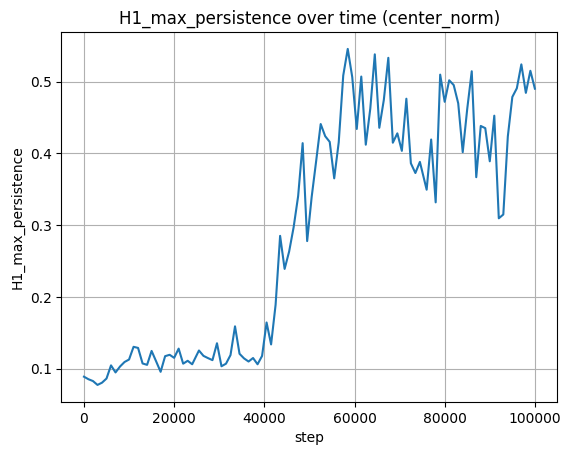

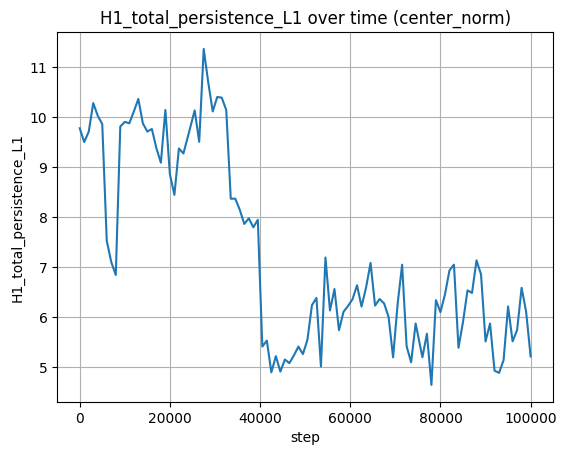

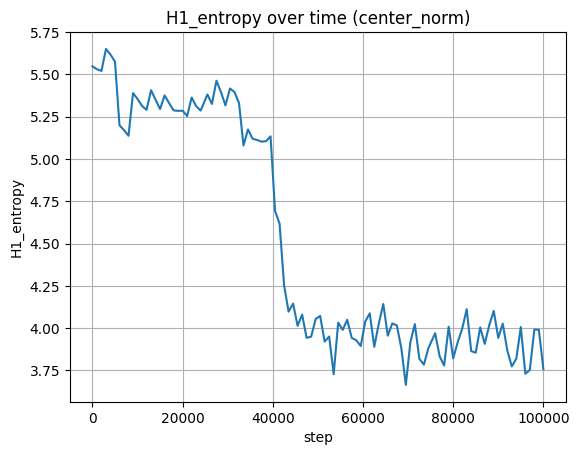

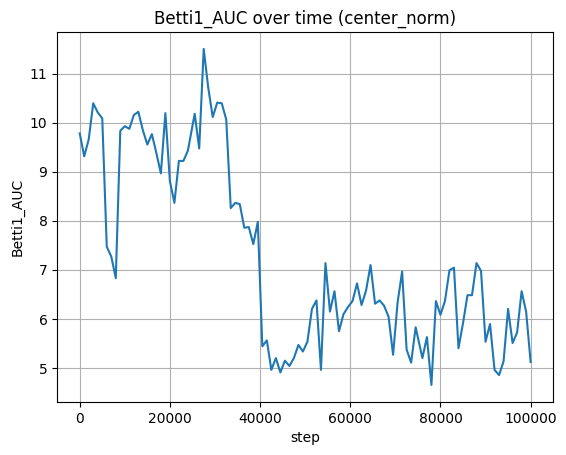

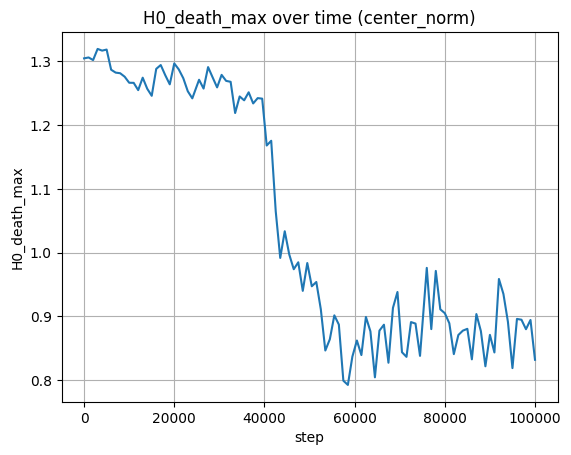

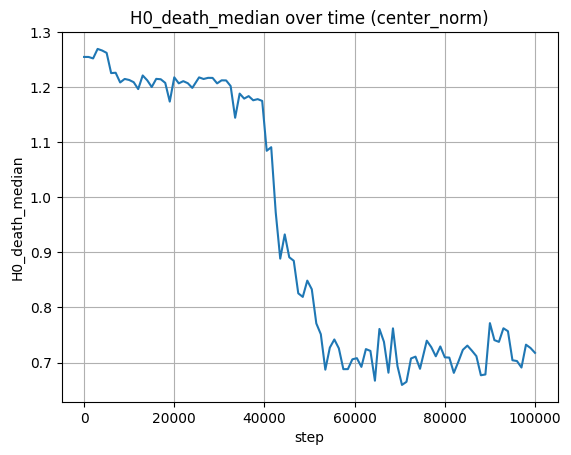

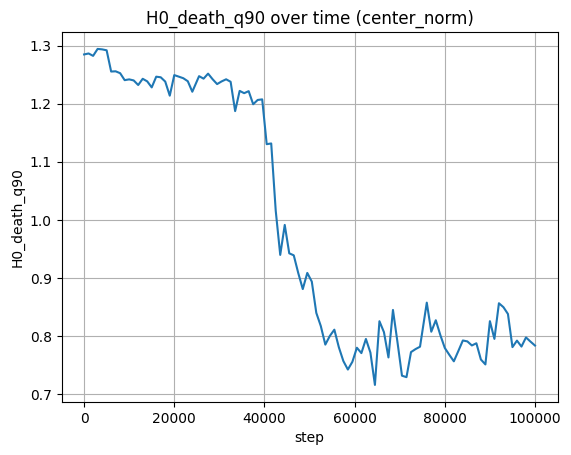

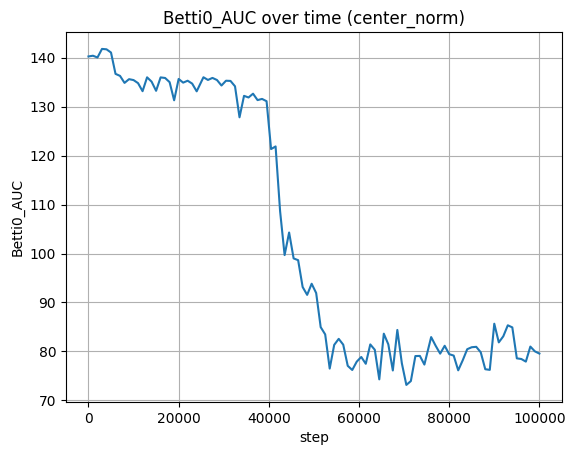

In [7]:
records = run_tda_over_time("./runs/modadd_grokking_03", n_slices=100, pre_mode="center_norm", dist_q=0.95, maxdim=1)

In [8]:


def pick_6_steps(records):
    steps = np.array([r["step"] for r in records], dtype=int)
    # 5 个覆盖时间轴
    idxs = [0, len(steps)//4, len(steps)//2, (3*len(steps))//4, len(steps)-1]
    base = [int(steps[i]) for i in idxs]

    # 1 个 H1_max_pers 最大（“最有信号”）
    h1_max = np.array([r.get("H1_max_pers", 0.0) for r in records], dtype=float)
    s_peak = int(steps[int(np.argmax(h1_max))])

    picked = []
    seen = set()
    for s in base + [s_peak]:
        if s not in seen:
            picked.append(s); seen.add(s)
    # 如果去重后不足 6（比如 peak 恰好等于某个 base），就补一些均匀点
    k = 0
    while len(picked) < 6 and k < len(steps):
        s = int(steps[k])
        if s not in seen:
            picked.append(s); seen.add(s)
        k += max(1, len(steps)//50)
    return picked[:6]


from persim import plot_diagrams

def plot_ph_for_steps(out_dir, steps_to_plot, pre_mode="center_norm", dist_q=0.95, maxdim=1):
    fig_dir = os.path.join(out_dir, "ph_figs")
    os.makedirs(fig_dir, exist_ok=True)

    for step in steps_to_plot:
        # 你已有的函数：load_tok_emb(out_dir, step), preprocess_points(X, mode), choose_thresh_from_dist(X,q)
        X_raw = load_tok_emb(out_dir, step)                       # (p,d)
        X = preprocess_points(X_raw, mode=pre_mode)               # 建议 center_norm
        thresh = choose_thresh_from_dist(X, q=dist_q)             # 自适应 epsilon_max

        res = ripser(X, maxdim=maxdim, thresh=thresh)
        dgms = res["dgms"]                                        # [H0, H1]

        # ---- persistence diagram (H0/H1 in one figure) ----
        plt.figure(figsize=(6, 5))
        plot_diagrams(dgms, show=False)  # 会同时画 H0/H1
        plt.title(f"Persistence Diagrams (H0/H1) | step={step} | {pre_mode} | thresh={thresh:.4f}")
        plt.tight_layout()
        p = os.path.join(fig_dir, f"pd_step_{step:07d}_{pre_mode}.png")
        plt.savefig(p, dpi=220)
        plt.close()

        # ---- optional: separate H0 and H1 ----
        for k in [0, 1]:
            if k >= len(dgms): 
                continue
            plt.figure(figsize=(6, 5))
            plot_diagrams([dgms[k]], show=False)
            plt.title(f"PD H{k} | step={step} | {pre_mode} | thresh={thresh:.4f}")
            plt.tight_layout()
            p = os.path.join(fig_dir, f"pd_H{k}_step_{step:07d}_{pre_mode}.png")
            plt.savefig(p, dpi=220)
            plt.close()

        print("Saved PD plots for step", step)


In [9]:
steps6 = pick_6_steps(records)
print("Picked 6 steps:", steps6)
plot_ph_for_steps("./runs/modadd_grokking_03", steps6, pre_mode="center_norm", dist_q=0.95, maxdim=1)


Picked 6 steps: [1, 25500, 50500, 76000, 100000, 58500]


c:\Users\tangy\.conda\envs\env_01\lib\site-packages\ripser\ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


Saved PD plots for step 1


c:\Users\tangy\.conda\envs\env_01\lib\site-packages\ripser\ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


Saved PD plots for step 25500


...

Saved PD plots for step 76000


c:\Users\tangy\.conda\envs\env_01\lib\site-packages\ripser\ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


Saved PD plots for step 100000


c:\Users\tangy\.conda\envs\env_01\lib\site-packages\ripser\ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


Saved PD plots for step 58500
